In [ ]:
## Using data from Sergeev et al. (2022)

## In this notebook we:
## 1. Load the data for Hab 1 TRAPPIST-1e with 1 bar surface pressure (selecting first point in vertial surface temp array)
## 2. Create a global surface temperature map
## 3. Constrain the substellar point
## 4. Load the air pressures and air temperatures as functions of model level number
## 5. Both now have a common coordinate so can be plotted against each other to create a temperature profile w.r.t pressure

In [1]:
import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.coord
import aeolus.calc
import stratify
import warnings

In [2]:
UM_THAI = iris.load('/data/cluster4/jj22956/thunderstruck_files/Hab1_UM_1_10.nc')
UM_THAI

/home/jj22956/.local/lib/python3.12/site-packages/iris/loading.py:717: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)


[<iris 'Cube' of TOTAL COLUMN Q (WATER VAPOUR PATH) / (unknown) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of LAYER CLD LIQ RE * LAYER CLD WEIGHT / (unknown) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of OPEN OCEAN FRACTION / (1) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of UPWARD LW FLUX ON LEVELS AND BANDS / (unknown) (time: 244; LW radiation bands: 12; atmosphere_hybrid_height_coordinate: 1; latitude: 90; longitude: 144)>,
<iris 'Cube' of LIQUID CLOUD FRACTION IN EACH LAYER / (1) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of FROZEN CLOUD FRACTION IN EACH LAYER / (1) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of TEMPERATURE       INCR: bdy layer / (unknown) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of TOTAL CLOUD AMOUNT MAX/RANDOM OVERLP / (1) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of LAYER CLOUD WEIGHT FOR MICROPHYSICS / (unknown) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of BULK CLOUD FRACTION IN EACH LAYER / (1) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of air_pressure / (Pa) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of air_pressure / (Pa) (time: 244; atmosphere_hybrid_height_coordinate: 41; latitude: 90; longitude: 144)>,
<iris 'Cube' of air_temperature / (K) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of atmosphere_cloud_ice_content / (kg m-2) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of atmosphere_cloud_liquid_water_content / (kg m-2) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of eastward_wind / (m s-1) (time: 244; atmosphere_hybrid_height_coordinate: 41; latitude: 90; longitude: 144)>,
<iris 'Cube' of mass_fraction_of_cloud_ice_in_air / (1) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of mass_fraction_of_cloud_liquid_water_in_air / (1) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of northward_wind / (m s-1) (time: 244; atmosphere_hybrid_height_coordinate: 41; latitude: 91; longitude: 144)>,
<iris 'Cube' of relative_humidity / (%) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of specific_humidity / (1) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of surface_downwelling_shortwave_flux_in_air / (W m-2) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of surface_net_downward_longwave_flux / (W m-2) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of surface_temperature / (K) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of tendency_of_air_temperature_due_to_longwave_heating / (K s-1) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of tendency_of_air_temperature_due_to_shortwave_heating / (K s-1) (time: 244; -- : 42; latitude: 90; longitude: 144)>,
<iris 'Cube' of toa_incoming_shortwave_flux / (W m-2) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of toa_outgoing_longwave_flux / (W m-2) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of toa_outgoing_longwave_flux_assuming_clear_sky / (W m-2) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of toa_outgoing_shortwave_flux / (W m-2) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of toa_outgoing_shortwave_flux_assuming_clear_sky / (W m-2) (time: 244; latitude: 90; longitude: 144)>,
<iris 'Cube' of upward_air_velocity / (m s-1) (time: 244; -- : 42; latitude: 90; longitude: 144)>]

In [3]:
air_temperature = UM_THAI[12]
# air_temperature
air_pressure = UM_THAI.extract_cube('m01s00i408')
# print(air_pressure)

In [4]:
# Temporal mean of air temperature and pressure

airtemp_t_mean = aeolus.calc.stats.time_mean(air_temperature)
airpressure_t_mean = aeolus.calc.stats.time_mean(air_pressure)
# print(airtemp_t_mean)
print(airpressure_t_mean)

air_pressure / (Pa)                         (-- : 42; latitude: 90; longitude: 144)
    Dimension coordinates:
        latitude                                -             x              -
        longitude                               -             -              x
    Auxiliary coordinates:
        Fraction of orographic height           x             -              -
        atmosphere_hybrid_height_coordinate     x             -              -
        height_above_reference_ellipsoid        x             -              -
        model_level_number                      x             -              -
    Scalar coordinates:
        time                                2009-12-09 10:00:00, bound=(2009-11-09 01:00:00, 2010-01-08 19:00:00)
    Cell methods:
        0                                   time: point
        1                                   time: mean
    Attributes:
        Conventions                         'CF-1.6'
        STASH                               m01s00i4

/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'time', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'time'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'time', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'time'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour,

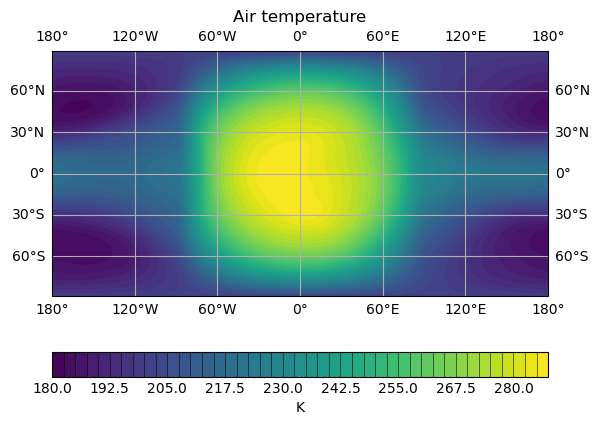

In [5]:
qplt.contourf(airtemp_t_mean[0], 50)
plt.gca().gridlines(draw_labels=True)

In [6]:
substellar_temp = airtemp_t_mean.extract(iris.Constraint(longitude = 0, latitude = 0))
substellar_pressure = airpressure_t_mean.extract(iris.Constraint(longitude = 0, latitude = 0))

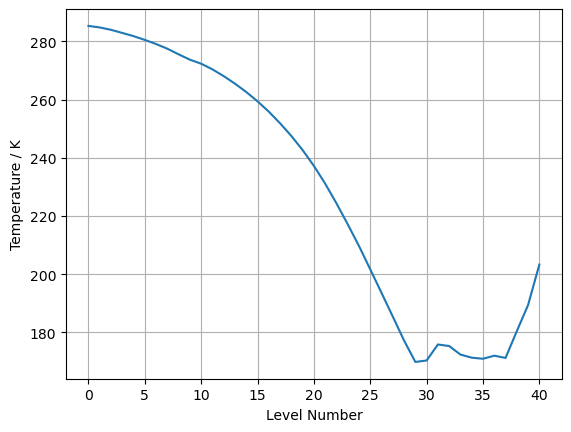

In [7]:
iplt.plot(substellar_temp)
plt.ylabel('Temperature / K')
plt.xlabel('Level Number')
plt.grid()
plt.show()

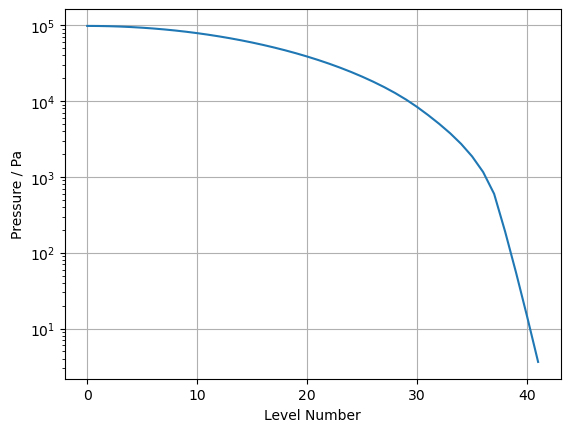

In [8]:
iplt.plot(substellar_pressure)
plt.ylabel('Pressure / Pa')
plt.xlabel('Level Number')
plt.yscale('log')
plt.grid()
plt.show()

In [9]:
AIRTEMP = substellar_temp.data
AIRPRESSURE = substellar_pressure.data
print(len(AIRTEMP), len(AIRPRESSURE))

42 42


In [10]:
AIRTEMP_FLAT = AIRTEMP.flatten()
AIRPRESSURE_FLAT = AIRPRESSURE.flatten()
temps = AIRTEMP_FLAT
pressures = AIRPRESSURE_FLAT

print(len(AIRPRESSURE_FLAT), len(AIRTEMP_FLAT))

42 42


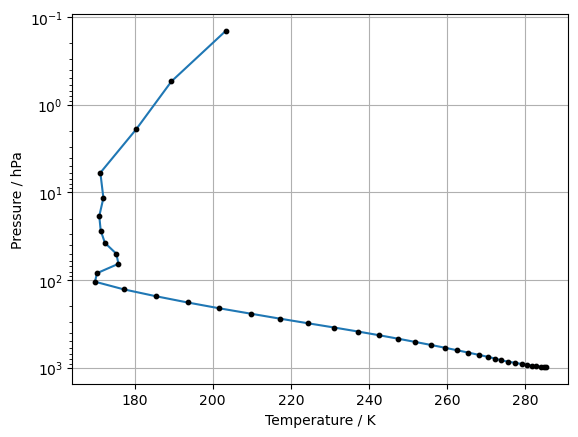

In [11]:
plt.plot(temps, pressures/100)
plt.scatter(temps, pressures/100, s = 10, facecolor = 'black', zorder = 3)
plt.yscale('log')
plt.gca().invert_yaxis()
plt.xlabel('Temperature / K')
plt.ylabel('Pressure / hPa')
plt.grid()
plt.show()

In [12]:
print(np.where(pressures<10000))
print(pressures[28], pressures[37])

(array([30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]),)
12758.62 597.011


In [13]:
## This is for the whole range

# z = np.polyfit(pressures, temps, 30)
# function = np.poly1d(z)

# test_p = np.linspace(0, 100000, 100)
# test_t = function(test_p)

In [14]:
## This is for the whole range

# plt.plot(temps, pressures/100, '-', test_t, test_p/100, '--')
# plt.yscale('log')
# plt.gca().invert_yaxis()
# plt.xlabel('Temperature / K')
# plt.ylabel('Pressure / hPa')
# plt.grid()
# plt.show()

In [15]:
## This is for the stratosphere

z = np.polyfit(pressures[28:41], temps[28:41], 7)
function = np.poly1d(z)

test_p = np.linspace(10, 12700, 50)
test_t = function(test_p)
# print(test_t)

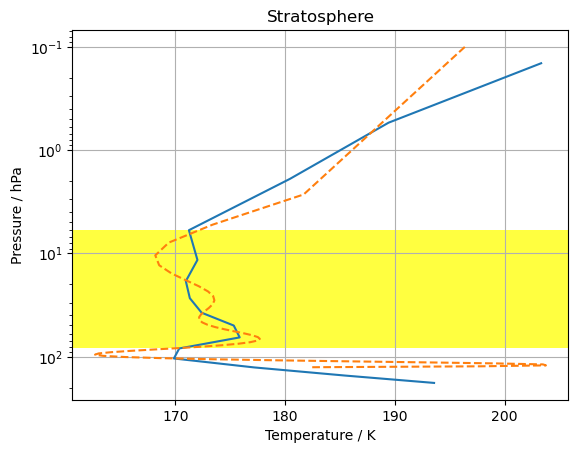

In [16]:
plt.plot(temps[26:41], pressures[26:41]/100, '-', test_t, test_p/100, '--')
plt.yscale('log')
y1 = 597.011
y2 = 8352.357
plt.axhspan(y1/100, y2/100, color='yellow', alpha=0.75, lw=0) # Shade the area representing the stratosphere
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel('Pressure / hPa')
plt.title('Stratosphere')
plt.grid()
plt.show()

In [17]:
p = np.arange(0, 6000, 100)
temp = np.zeros(len(p))

def temp_strat(pressure):
    """International Standard Atmosphere stratospheric temperature."""
    if pressure > 5474.9:
        return 216.6
    elif pressure > 868.02:
        return 216.6 + 12.0 * np.log(pressure / 5474.9) / np.log(868.02 / 5474.9)
    elif pressure > 110.91:
        return 228.6 + 42.0 * np.log(pressure / 868.02) / np.log(110.91 / 868.02)
    elif pressure > 66.939:
        return 270.6
    else:
        return 270.6 - 56.0 * np.log(pressure / 66.939) / np.log(3.9564 / 66.939)


print(len(temp))

60


In [18]:
for i in range(len(p)):
    pressure = p[i]
    temp[i] = temp_strat(pressure)



/tmp/ipykernel_626216/608808720.py:15: RuntimeWarning: divide by zero encountered in log
  return 270.6 - 56.0 * np.log(pressure / 66.939) / np.log(3.9564 / 66.939)


In [19]:
# plt.plot(temp, p)

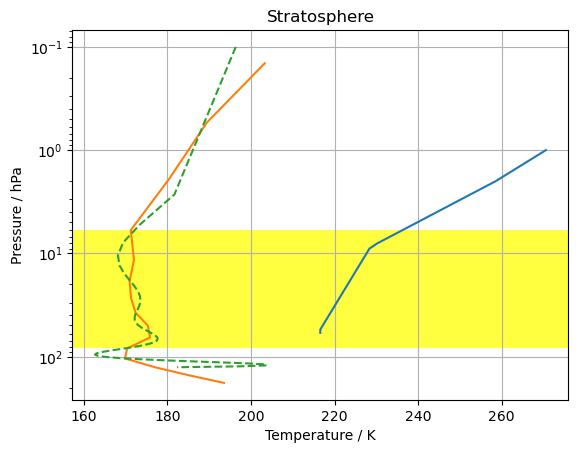

In [20]:
plt.plot(temp, p/100, temps[26:41], pressures[26:41]/100, '-', test_t, test_p/100, '--')
plt.yscale('log')
y1 = 597.011
y2 = 8352.357
plt.axhspan(y1/100, y2/100, color='yellow', alpha=0.75, lw=0) # Shade the area representing the stratosphere
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel('Pressure / hPa')
plt.title('Stratosphere')
plt.grid()
plt.show()

In [21]:
function

poly1d([-1.02812606e-24,  4.38243525e-20, -7.37845873e-16,  6.26892352e-12,
       -2.85054467e-08,  6.76018095e-05, -7.35174219e-02,  1.97089228e+02])

In [22]:
UM_THAI_tempprofile_coefficients = np.array([-1.02812606e-24,  4.38243525e-20, -7.37845873e-16,  6.26892352e-12,
       -2.85054467e-08,  6.76018095e-05, -7.35174219e-02,  1.97089228e+02])

In [23]:
UM_THAI_tempprofile_coefficients

array([-1.02812606e-24,  4.38243525e-20, -7.37845873e-16,  6.26892352e-12,
       -2.85054467e-08,  6.76018095e-05, -7.35174219e-02,  1.97089228e+02])